In [9]:
# --- Импорт библиотек ---
import numpy as np
import cupy as cp
import time
import pandas as pd
import matplotlib.pyplot as plt
from functools import wraps
import torch
from torch import nn
import cv2
import matplotlib.image as mpimg
from tqdm import tqdm
from numba import cuda, njit, jit, prange
import numba
import os
import glob
from PIL import Image
import torchvision.transforms as transforms
import pickle

In [10]:
# --- Загрузка данных ---
# Загрузка датасета

# Вместо скачивания через kagglehub, просто указываем путь к папке
path_dogs_and_cats = r"D:\Git\ml_CUDA\path_dogs_and_cats"  # или точное имя папки, если оно другое

print("Path to dataset files:", path_dogs_and_cats)
# path_dogs_and_cats = kagglehub.dataset_download("aleemaparakatta/cats-and-dogs-mini-dataset")
# print("Path to dataset files:", path_dogs_and_cats)

# Пути к папкам с изображениями
path_to_dogs = path_dogs_and_cats+'/dogs_set'
path_to_cats = path_dogs_and_cats+'/cats_set'
cat_img = path_to_cats+'/cat.4005.jpg'
dog_img = path_to_dogs+'/dog.4005.jpg'
base_dir = path_dogs_and_cats

Path to dataset files: D:\Git\ml_CUDA\path_dogs_and_cats


In [11]:
# --- Функции для замера времени, отображения результатов и загрузки данных ---

def time_logger(func):
    """Декоратор, засекает время выполнения функции.
      Каждая функция выполняется 10 раз, после чего считается среднее время выполнения
    """
    @wraps(func)
    def wrapper(*args, **kwargs):
        avg_time = 0 # Среднее время выполнения
        k = 10 # количество выполнеий
        for i in range(k):
          start_time = time.time()  # Время начала
          result = func(*args, **kwargs)  # Запуск функции
          end_time = time.time()  # Время окончания

          execution_time = end_time - start_time
          avg_time += execution_time
        print(f"Среднее время выполнения: {avg_time/k:.6f} секунд")
        return result, avg_time
    return wrapper

def addToTable(df, n_val, c_val, column):
  df[column] = [n_val, c_val]
  return df.copy()

def tableGrathOut(arr_n, arr_c, arr_val):
  df_timeTable = pd.DataFrame({}, index=['numpy time (sec.)','cupy time (sec.)'])
  for index, value in enumerate(arr_val):
    df_timeTable = addToTable(df_timeTable, arr_n[index], arr_c[index], value)
  print('Таблица времени работы двух фреймворков:')
  print(df_timeTable)
  # Данные для линии X
  x = arr_val
  # Данные для линий по Y
  y1 = arr_n
  y2 = arr_c

  xlabl = 'Размерность'
  ylabl = 'Время выполнения в сек.'
  # Построение графиков
  plt.plot(x, y1, label='numpy time', color='blue', linewidth=2)
  plt.plot(x, y2, label='cupy time', color='red', linewidth=2)

  plt.title('График времени работы двух фреймворков')
  plt.xlabel(xlabl)
  plt.ylabel(ylabl)
  plt.legend()
  plt.grid(True)

  # Вывод графика
  plt.show()

  # по отдельности

  # Создание сетки: 1 строка, 2 столбца
  fig, (ax1, ax2) = plt.subplots(1, 2)

  # Первый график
  ax1.plot(x, y1, color='blue')
  ax1.set_title('numpy time')
  ax1.set_xlabel(xlabl)
  ax1.set_ylabel(ylabl)

  # Второй график
  ax2.plot(x, y2, color='red')
  ax2.set_title('cupy time')
  ax2.set_xlabel(xlabl)
  ax2.set_ylabel(ylabl)

  # Настройка расстояния между графиками
  plt.tight_layout()
  plt.show()

def show_plt_img(img):
  plt.imshow(img)
  plt.show()

In [12]:
# --- Классы слоев и функций активации ---

class BaseLayer(nn.Module):
    ''' класс `BaseLayer`, от которого будут наследоваться слои для вашей NN '''
    def __init__(self, **kwargs):
        super(BaseLayer, self).__init__()

    def forward(self, X):
        """Прямой проход, возвращает выход и кэш активаций с выводом среднего времени"""
        pass

    def forward_no_Time(self, X):
        """Прямой проход, возвращает выход и кэш активаций"""
        pass
    def update(self, grad, lr):
        pass

    def state_dict(self, grad, lr):
        """Настройки слоя"""
        return {}
    def load_state_dict(self, grad, lr):
        """Загрузить слоя"""
        pass

    def backward(self, dL_dy, cache):
        """Обратный проход, возвращает градиенты и dL_dx, с выводом среднего времени"""
        pass

    def backward_no_Time(self, dL_dy, cache):
        """Обратный проход, возвращает градиенты и dL_dx"""
        pass

@njit
def numba_matrix_multipl(x, y):
      return x * y

@njit
def sum_matrix(x):
    '''
    sum по axis 1, 2, 3
    '''
    n0 = x.shape[0]
    res = np.zeros(n0)
    for i in range(n0):
        res[i] = np.sum(x[i, :, :, :])
    return res
    # return np.sum(x, axis=(1, 2, 3))

@njit
def conv_forward_njit(X, W, bias, pad, stride, xp):
  n, c, image_height, image_width = X.shape
  out_chanels, _, kernel_height, kernel_width = W.shape
  h_pad = image_height + 2 * pad
  w_pad = image_width + 2 * pad
  h_out = (h_pad - kernel_height) // stride + 1
  w_out = (w_pad - kernel_width) // stride + 1
  output = np.zeros((n, out_chanels, h_out, w_out), dtype=X.dtype)
  for i in prange(h_out):
    for j in prange(w_out):
      strideI = i*stride
      strideJ = j*stride
      patch = xp[:, :, strideI : strideI + kernel_height,
                  strideJ : strideJ + kernel_width]
      for oc in prange(out_chanels):
        multipl = numba_matrix_multipl(patch, W[oc : oc + 1, :, :, :])
        # (njit) не поддерживает передачу кортежа осей (tuple) в функцию np.sum(axis=...), поэтому через цикл
        output[:, oc, i, j] = sum_matrix(multipl)
  output += bias[None, :, None, None]
  return output

@njit
def conv_backward_njit(Y, cacheX, W, pad, stride, xp):
  n, c, image_height, image_width = cacheX.shape
  out_chanels, _, kernel_height, kernel_width = W.shape
  h_pad = image_height + 2 * pad
  w_pad = image_width + 2 * pad
  dXp = np.zeros_like(xp)
  dW = np.zeros_like(W)
  db = np.zeros_like(W[:, 0, 0, 0])
  h_out, w_out = Y.shape[2], Y.shape[3]

  for i in range(h_out):
    for j in range(w_out):
      strideI = i*stride
      strideJ = j*stride
      patch = xp[:, :, strideI : strideI + kernel_height,
                  strideJ : strideJ + kernel_width]
      for oc in range(out_chanels):
        dW[oc] += np.sum(patch * (Y[:, oc, i, j])[:, None, None, None], axis=0)
      for n_i in range(n):
        for oc in range(out_chanels):
          dXp[n_i, :, strideI : strideI + kernel_height,
                  strideJ : strideJ + kernel_width] += W[oc] + Y[n_i, oc, i, j]
  for oc in range(out_chanels):
    db[oc] = np.sum(Y[:, oc, :, :])

  if pad >0:
    dX = dXp[:, :, pad:-pad, pad:-pad]
  else:
    dX = dXp
  return dX, dW/n, db/n

In [13]:
# --- Сверточный слой (Conv2d) ---
class Conv2d_layer(BaseLayer):
    # инициализирует основные параметры свёртки
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding = 1, bias = True, isDevice=False, checkMethod = False):
        '''
        Args:
            in_channels (int): Number of input channels.
            out_channels (int): Number of output channels.
            kernel_size (int or tuple[int, int]): Size of the convolutional kernel.
            stride (int, optional): Stride value for the convolution operation. Default is 1.
            isDevice (bool): compute with numba
            check_mmethod (bool): compute with simple kernel
        '''
        super(Conv2d_layer, self).__init__()
        self.rng = np.random.RandomState(42)
        # количество каналов на входе свёрточного слоя. Для RGB будет = 3
        self.in_channels = in_channels
        # количество каналов на выходе свёрточного слоя. Для RGB будет = 3
        self.out_channels = out_channels
        self.checkMethod = checkMethod
        # размер ядра свёртки, если = 3, то ядро свёртки будет размером 3x3
        if isinstance(kernel_size, int):
          self.kernel_size = kernel_size
        elif isinstance(kernel_size, tuple) and len(kernel_size) == 1:
          self.kernel_size = kernel_size[0]
        # Шаг свёртки
        K = self.kernel_size
        self.kernels = kernelMatrix = np.ones(
            (out_channels, in_channels, K, K)
          ) if self.checkMethod else self.rng.rand(
              out_channels, in_channels, K, K
          ).astype(np.float32) * np.sqrt(2.0 / (in_channels * K**2))
        self.stride = stride
        self.padding = padding
        if checkMethod == False:
          self.bias = np.array(self.rng.uniform(- 0.5, 0.5, size=out_channels), dtype=np.float32)
        else:
          self.bias = np.zeros((out_channels,), dtype=np.float32)

        self.isDevice = isDevice

    def cross_correlation(self, X):
      W = self.kernels
      pad = self.padding
      stride = self.stride
      n, c, image_height, image_width = X.shape
      out_chanels, _, kernel_height, kernel_width = W.shape
      h_pad = image_height + 2 * pad
      w_pad = image_width + 2 * pad
      xp = np.pad(X, ((0,0),(0,0),(pad, pad),(pad, pad)), mode='constant')
      h_out = (h_pad - kernel_height) // stride + 1
      w_out = (w_pad - kernel_width) // stride + 1
      output = np.zeros((n, out_chanels, h_out, w_out), dtype=X.dtype)
      for i in tqdm(range(h_out)):
        for j in range(w_out):
          strideI = i*stride
          strideJ = j*stride
          patch = xp[:, :, strideI : strideI + kernel_height,
                     strideJ : strideJ + kernel_width]
          for oc in range(out_chanels):

            output[:, oc, i, j] = np.sum(patch * W[oc : oc + 1, :, :, :], axis=(1, 2, 3))
      output += self.bias[None, :, None, None]
      print()
      return output

    def cross_correlation_backw(self, Y, cacheX):
      W = self.kernels
      pad = self.padding
      stride = self.stride
      n, c, image_height, image_width = cacheX.shape
      out_chanels, _, kernel_height, kernel_width = W.shape
      h_pad = image_height + 2 * pad
      w_pad = image_width + 2 * pad
      xp = np.pad(cacheX, ((0,0),(0,0),(pad, pad),(pad, pad)), mode='constant')
      dXp = np.zeros_like(xp)
      dW = np.zeros_like(W)
      db = np.zeros_like(W[:, 0, 0, 0])
      h_out, w_out = Y.shape[2], Y.shape[3]

      for i in tqdm(range(h_out)):
        for j in range(w_out):
          strideI = i*stride
          strideJ = j*stride
          patch = xp[:, :, strideI : strideI + kernel_height,
                     strideJ : strideJ + kernel_width]
          for oc in range(out_chanels):
            dW[oc] += np.sum(patch * (Y[:, oc, i, j])[:, None, None, None], axis=0)
          for n_i in range(n):
            for oc in range(out_chanels):
              dXp[n_i, :, strideI : strideI + kernel_height,
                     strideJ : strideJ + kernel_width] += W[oc] + Y[n_i, oc, i, j]
      for oc in range(out_chanels):
        db[oc] = np.sum(Y[:, oc, :, :])

      if pad >0:
        dX = dXp[:, :, pad:-pad, pad:-pad]
      else:
        dX = dXp
      print()
      return dX, dW/n, db/n
    def cross_correlation_forw_device(self, X):
      # njit не поддерживает функцию pad, поэтому вчисления производятся здесь
      pad = self.padding
      xp = np.pad(X, ((0,0),(0,0),(pad, pad),(pad, pad)), mode='constant')
      return conv_forward_njit(X, self.kernels, self.bias, pad, self.stride, xp)

    def cross_correlation_backw_device(self, Y, cacheX):
      # njit не поддерживает функцию pad, поэтому вчисления производятся здесь
      pad = self.padding
      xp = np.pad(cacheX, ((0,0),(0,0),(pad, pad),(pad, pad)), mode='constant')
      return conv_backward_njit(Y, cacheX, self.kernels, pad, self.stride, xp)

    def forward_func(self, X):
      cross_correlation_func = self.cross_correlation if self.isDevice ==False else self.cross_correlation_forw_device
      output = cross_correlation_func(X)
      cache = (X, output)
      return output, cache

    def backward_func(self, dY, cache):
      X, _ = cache
      cross_correlation_func = self.cross_correlation_backw if self.isDevice ==False else self.cross_correlation_backw_device
      dX, dW, db = cross_correlation_func(dY, X)
      grad = {'weights': dW, 'bias': db}
      return dX, grad

    @time_logger
    def forward(self, X):
      return self.forward_func(X)

    def forward_no_Time(self, X):
      return self.forward_func(X)

    @time_logger
    def backward(self, X, cache):
      return self.backward_func(X, cache)

    def backward_no_Time(self, X, cache):
      return self.backward_func(X, cache)

    def update(self, grad, lr):
      self.kernels -= lr * grad['weights']

    def state_dict(self):
      return {
        'in_channels': self.in_channels,
        'out_channels': self.out_channels,
        'stride': self.stride,
        'kernel_size': self.kernel_size,
        'weights': self.kernels,
        'padding': self.padding,
        'bias': self.bias,
        'isDevice': self.isDevice
      }

    def load_state_dict(self, state):
      self.in_channels = state['in_channels']
      self.out_channels = state['out_channels']
      self.kernel_size = state['kernel_size']
      self.stride = state['stride']
      self.kernels = state['weights']
      self.isDevice = state['isDevice']
      self.bias = state['bias']
      self.padding = state['padding']

In [14]:
# --- ReLU ---
@jit(parallel=True,fastmath=True)
def numba_maximum(x):
      return np.maximum(0,x)

@jit(parallel=True,fastmath=True)
def numba_maximum_backward(x, input_matrix):
      return (x > 0) * input_matrix

class ReLU_layer(BaseLayer):
    def __init__(self, isDevice=False, checkMethod = False):
        super(ReLU_layer, self).__init__()
        self.checkMethod = checkMethod
        self.isDevice = isDevice

    def forward_func(self, x):
      self.x = x
      if self.isDevice:
        return numba_maximum(x), self.x
      else:
        return np.maximum(0,x), self.x

    def backward_func(self, input_matrix, cahce):
      x = cahce
      if self.isDevice:
        return numba_maximum_backward(x, input_matrix), {}
      else:
        return (x > 0) * input_matrix, {}

    @time_logger
    def forward(self, X):
      return self.forward_func(X)

    def forward_no_Time(self, X):
      return self.forward_func(X)

    @time_logger
    def backward(self, X, cahce):
      return self.backward_func(X, cahce)

    def backward_no_Time(self, X, cahce):
      return self.backward_func(X, cahce)

    def state_dict(self):
      return {
        'isDevice': self.isDevice
      }
    def load_state_dict(self, state):
      self.isDevice = state['isDevice']

In [15]:
# --- Linear (Dense) Layer ---
@njit
def numba_mean(x):
  return np.sum(x, axis=0) / x.shape[0]
  # return np.mean(x, axis=0)

@njit
def batched_matmul(x, weights, bias=None):
    """
    Performs batched matrix multiplication for 3D tensors x 2D.
    x: (batch, n, h, m)
    weights: (m, p)
    bias: (1, p)
    Returns: (batch, n, p)
    """
    if (x.ndim == 2):
      dot_x =  np.dot(x.astype(np.float32), weights.astype(np.float32))
      return dot_x if bias==None else dot_x + bias

    batch, n, h, m = x.shape
    _, p = weights.shape
    # предполагаем, что у нас поддерживается только один батч

    R = np.empty((batch, n, h, p), dtype=np.float32)
    for b in prange(batch):
      C = np.empty((n, h, p), dtype=np.float32)
      # т.к. numba поддерживает матричное умножение только для 2D, перемножается для каждого батча
      for i in prange(n):
          patch = x[0][i].astype(np.float32)
          C[i] = np.dot(patch, weights.astype(np.float32))
      R[b] = C
    return R if bias==None else R + bias

class Linear_layer(BaseLayer):
    def __init__(self, in_features, out_features, bias=True, isDevice=False, checkMethod = False):
        super(Linear_layer, self).__init__()
        '''
        y = Ax+b
        '''
        self.in_features = in_features
        self.out_features = out_features
        self.rng = np.random.RandomState(42)
        # Случайные веса
        self.checkMethod = checkMethod
        self.weights = (np.ones((out_features, in_features)) if checkMethod else self.rng.rand(
              out_features, in_features).astype(np.float32) * np.sqrt(2.0 / (in_features)))
        # bias
        if bias and not checkMethod:
            self.bias = self.rng.uniform(- 0.5, 0.5, size=out_features)
        else:
            self.bias = np.zeros(out_features)
        self.isDevice = isDevice

    def forward_func(self, x):
      self.x = x
      if self.isDevice:

        result = batched_matmul(x.astype(np.float32), self.weights.T.astype(np.float32), self.bias.astype(np.float32))
      else:
        result = np.dot(x,  self.weights.T) + self.bias
      return result, self.x

    def backward_func(self, input_matrix, cache):
      X = cache
      if self.isDevice:
        dW = batched_matmul(input_matrix.T.astype(np.float32), X.astype(np.float32), None) / X.shape[0]
        db = numba_mean(input_matrix.astype(np.float32))
        result = batched_matmul(input_matrix.astype(np.float32), self.weights.astype(np.float32), None)
      else:
        dW = np.dot(input_matrix.T.astype(np.float32), X) / X.shape[0]
        db = np.mean(input_matrix, axis=0)
        result = np.dot(input_matrix, self.weights)
      return result, {'weights': dW, 'bias': db}

    @time_logger
    def forward(self, X):
      return self.forward_func(X)

    def forward_no_Time(self, X):
      return self.forward_func(X)

    @time_logger
    def backward(self, X, cache):
      return self.backward_func(X, cache)

    def backward_no_Time(self, X, cache):
      return self.backward_func(X, cache)

    def update(self, grad, lr):
      self.weights -= lr * grad['weights']
      self.bias -= lr * grad['bias']

    def state_dict(self):
      return {
        'in_features': self.in_features,
        'out_features': self.out_features,
        'bias': self.bias,
        'weights': self.weights,
        'isDevice': self.isDevice
      }

    def load_state_dict(self, state):
      self.in_features = state['in_features']
      self.out_features = state['out_features']
      self.bias = state['bias']
      self.weights = state['weights']
      self.isDevice = state['isDevice']

In [16]:
# --- MaxPool2D ---
@njit
def numba_get_max(x):
  return np.max(x)

@njit
def numba_maxPoolFunc(image, output_height, output_width, stride, kernel_size, output, mask):
  for i in range(output_height):
    for j in range(output_width):
      # Extract subsection (i*stride, j*stride) to ((i+1)*stride, (j+1)*stride)
      iStride = i * stride
      jStride = j * stride
      subsection = image[:, :,
        iStride : iStride + kernel_size[0],
        jStride : jStride + kernel_size[1],
      ]
      # Compute max value of the subsection and assign it to output
      output[:, :, i, j] = numba_get_max(subsection[0, 0, :, :])
      maxpos = (subsection == output[:, :, i, j][:,:,None,None])
      mask[:, :,
        iStride : iStride + kernel_size[0],
        jStride : jStride + kernel_size[1],
      ] = mask[:, :,
        iStride : iStride + kernel_size[0],
        jStride : jStride + kernel_size[1],
      ] | maxpos
  return output, mask

@njit
def numba_maxPoolFunc_back(output_height, output_width, Y, stride, kernel_size, output, mask):
  for h in range(output_height):
    for w in range(output_width):
      h_start, h_end = h * stride, h * stride + kernel_size[0]
      w_start, w_end = w * stride, w * stride + kernel_size[1]
      output[:,:,h_start : h_end, w_start : w_end] -= (mask[:,:,h_start : h_end, w_start : w_end] * Y[:,:,h:h+1,w:w+1])
  return output

class MaxPool2D_layer(BaseLayer):
    # инициализирует основные параметры свёртки
    def __init__(self, kernel_size, stride=1, isDevice=False, checkMethod = False):
        super(MaxPool2D_layer, self).__init__()
        # размер ядра свёртки, если = 3, то ядро свёртки будет размером 3x3
        if isinstance(kernel_size, int):
          self.kernel_size = (kernel_size, kernel_size)
        elif isinstance(kernel_size, tuple) and len(kernel_size) == 1:
          self.kernel_size = (kernel_size[0], kernel_size[0])
        # Шаг свёртки
        self.stride = stride
        self.rng = np.random.RandomState(42)
        self.isDevice = isDevice
        self.checkMethod = checkMethod
        # self.forward()

    # метод позволяет задавать весовые коэффициенты ядра свёртки
    # ниже в дочернем классе Conv2d мы его переопределим
    def set_kernel(self, kernel):
        self.kernel = kernel

    def maxPoolFunc(self, output_height, output_width, image, output, mask):
      # получение максимального значения из ядра
      for i in range(output_height):
        for j in range(output_width):
          # Extract subsection (i*stride, j*stride) to ((i+1)*stride, (j+1)*stride)
          iStride = i * self.stride
          jStride = j * self.stride
          subsection = image[:, :,
            iStride : iStride + self.kernel_size[0],
            jStride : jStride + self.kernel_size[1],
          ]
          # Compute max value of the subsection and assign it to output
          sub_max = np.max(subsection[0, 0, :, :])
          output[:, :, i, j] = sub_max
          maxpos = (subsection == output[:, :, i, j][:,:,None,None])
          mask[:, :,
            iStride : iStride + self.kernel_size[0],
            jStride : jStride + self.kernel_size[1],
          ] = mask[:, :,
            iStride : iStride + self.kernel_size[0],
            jStride : jStride + self.kernel_size[1],
          ] | maxpos
      return output, mask

    def maxPoolBackFunc(self, output_height, output_width, Y, output, mask):
      for h in range(output_height):
        for w in range(output_width):
          h_start, h_end = h * self.stride, h * self.stride + self.kernel_size[0]
          w_start, w_end = w * self.stride, w * self.stride + self.kernel_size[1]
          output[:,:,h_start : h_end, w_start : w_end] -= (mask[:,:,h_start : h_end, w_start : w_end] * Y[:,:,h:h+1,w:w+1])
      return output

    def forward_func(self, X):
      image = X

      n, c, h, w = image.shape  # Height, width, and number of channels in the image
      output_height = (h - self.kernel_size[0]) // self.stride + 1
      output_width = (w - self.kernel_size[1]) // self.stride + 1
      output_channels = c  # Number of channels in the image

      output = np.zeros((n, output_channels, output_height, output_width))
      mask = np.zeros_like(X, dtype=np.bool_)

      for channel in tqdm(range(output_channels)):
          if self.isDevice:
            output, mask = numba_maxPoolFunc(image, output_height, output_width, self.stride, self.kernel_size, output, mask)
          else:
            output, mask = self.maxPoolFunc(output_height, output_width, image, output, mask)
      print()
      return output, (image.shape, mask)

    def backward_func(self, Y, cache):
      input_shape, mask = cache

      n, c, h, w = Y.shape  # Height, width, and number of channels in the image
      output_height = h
      output_width = w
      output_channels = c  # Number of channels in the image

      output = np.zeros(input_shape)
      for channel in tqdm(range(output_channels)):
          if self.isDevice:
            output = numba_maxPoolFunc_back(output_height, output_width, Y, self.stride, self.kernel_size, output, mask)
          else:
            output = self.maxPoolBackFunc(output_height, output_width, Y, output, mask)
      print()
      return output, {}

    @time_logger
    def forward(self, X):
      return self.forward_func(X)

    def forward_no_Time(self, X):
      return self.forward_func(X)

    @time_logger
    def backward(self, X, cache):
      return self.backward_func(X, cache)

    def backward_no_Time(self, X, cache):
      return self.backward_func(X, cache)

    def state_dict(self):
      return {
        'stride': self.stride,
        'kernel_size': self.kernel_size,
        'isDevice': self.isDevice
      }

    def load_state_dict(self, state):
      self.stride = state['stride']
      self.kernel_size = state['kernel_size']
      self.isDevice = state['isDevice']

In [17]:
# --- SoftMax ---
@njit
def numba_sum_axis1_keepdims(x):
  return np.expand_dims(np.sum(x, axis=1), 1)

@njit
def numba_softmax(x):
  expX = np.exp(x)
  return expX / numba_sum_axis1_keepdims(expX)

@njit
def numba_softmax_bck(x, softmax_output):
  output = y * (x - numba_sum_axis1_keepdims(x*y))
  # Reshape back to original shape
  return output

@jit(parallel=True,fastmath=True)
def numba_exp(x):
  return np.exp(x)

class Softmax_layer(BaseLayer):
    def __init__(self, isDevice=False):
      super(Softmax_layer, self).__init__()
      self.isDevice = isDevice

    def forward_func(self, x):
        if self.isDevice:
          self.output = numba_softmax(x)
        else:
          expX = np.exp(x)
          self.output = expX / np.sum(expX, axis=1, keepdims=True)
        return self.output, self.output

    def backward_func(self, x, cache):
        y = cache
        if self.isDevice:
          return numba_softmax_bck(x, y), {}
        else:
            output = y * (x - np.sum(x*y, axis=1, keepdims=True))
            return output, {}

    @time_logger
    def forward(self, X):
      return self.forward_func(X)

    def forward_no_Time(self, X):
      return self.forward_func(X)

    @time_logger
    def backward(self, X, cache):
      return self.backward_func(X, cache)

    def backward_no_Time(self, X, cache):
      return self.backward_func(X, cache)

    def state_dict(self):
      return {
        'isDevice': self.isDevice
      }

    def load_state_dict(self, state):
      self.isDevice = state['isDevice']

In [18]:
# --- Flatten ---
@njit
def numba_reshape(x):
  return np.reshape(x, (x.shape[0], -1))

@njit
def numba_reshape_backward(X, input_shape):
  return X.reshape(input_shape)

class Flatten_layer(BaseLayer):
    # инициализирует основные параметры свёртки
    def __init__(self, isDevice=False):
      super(Flatten_layer, self).__init__()
      self.isDevice = isDevice

    def forward_func(self, x):
        # x shape: (batch_size, height, width, channels)
        self.input_shape = x.shape
        if self.isDevice:
          return numba_reshape(x), self.input_shape
        else:
          return x.reshape(x.shape[0], -1), self.input_shape

    def backward_func(self, X, cache):
      input_shape = cache
      if self.isDevice:
        return numba_reshape_backward(X, input_shape), {}
      else:
        return X.reshape(input_shape), {}

    @time_logger
    def forward(self, X):
      return self.forward_func(X)

    def forward_no_Time(self, X):
      return self.forward_func(X)

    @time_logger
    def backward(self, X, cache):
      return self.backward_func(X, cache)

    def backward_no_Time(self, X, cache):
      return self.backward_func(X, cache)

    def state_dict(self):
      return {
        'isDevice': self.isDevice
      }

    def load_state_dict(self, state):
      self.isDevice = state['isDevice']

In [19]:
# --- Функции потерь, оптимизатор и модель ---
class BaseLossFunction:
    def __init__(self):
        pass

    def __calc__(self, y_true, logits):
        pass

    def derivative(self, y_true, logits):
        pass

In [20]:
class CrossEntropyLoss(BaseLossFunction):
    def __init__(self):
        super(CrossEntropyLoss, self).__init__()

    def __call__(self, y_true, predicted):
        predicted = predicted.astype(np.float32)
        exp = np.exp(predicted - np.max(predicted, axis=1,keepdims=True))
        probs = exp /np.sum(exp, axis=1, keepdims=True)
        n = y_true.shape[0]
        if y_true.ndim ==1:
            loss = -np.mean(np.log(probs[np.arange(n), y_true] + 1e-5)) # добавим 1e-5, чтобы случайно не взять log(0)
        else:
            loss = -np.mean(np.sum(y_true * np.log(probs + 1e-5), axis=1))
        return loss

    def derivative(self, y_true, predicted):
      predicted = predicted.astype(np.float32)
      exp = np.exp(predicted - np.max(predicted, axis=1,keepdims=True))
      probs = exp /np.sum(exp, axis=1, keepdims=True)
      n = y_true.shape[0]
      if y_true.ndim ==1:
          grad = probs.copy()
          grad[np.arange(n), y_true] -= 1
          grad /=n
      else:
          grad = (probs - y_true) / n
      return grad

In [21]:
class BaseOptimizer:
    def __init__(self, loss_func, **kwargs):
        self.loss_func = loss_func

    def optimize(self, logits, cache, model):
        pass

In [22]:
class GDPtimizer(BaseOptimizer):
    def __init__(
        self,
        loss_func,
        learning_rate = 0.1,
        **kwargs,
    ):
        super.__init__(loss_func, **kwargs)
        self.learning_rate = learning_rate

    def optimize(self, X, y, model):
        """Запускает оптимизацию модели."""
        logits, cache = model.predict(X)
        loss = self.loss_func(y, logits)
        dL_dy = self.log_loss.derivative(y, logits)
        grads = model._get_grads(dL_dy, cache)
        model._update_weights(model, -self.learning_rate * grads)
        return loss

In [23]:
class Model(nn.Module):
    def __init__(self, layers=None, isOptimal=True):
      super().__init__()
      self.layers = layers if layers is not None else []

    def predict(self, X):
        """Прямой проход, возвращает выход и кэш активаций"""
        y = X
        cache = []
        print('----------forward---------')
        for layer in self.layers:
            print(layer.__class__.__name__, y.shape)
            y, c = layer.forward_no_Time(y)
            cache.append(c)
        return y, cache

    def _get_grads(self, dL_dy, cache):
        """Обратный проход, возвращает градиенты"""
        dy = dL_dy
        grads = []
        print('----------backward---------')
        for layer, c in zip(self.layers[::-1], cache[::-1]):
            print(layer.__class__.__name__, dy.shape)
            dy, grad = layer.backward_no_Time(dy, c)
            grads.insert(0, grad)
        return grads

    def _update_weights(self, grads, learning_rate):
        for layer, grad in zip(self.layers,grads):
          func = getattr(layer, 'update', None)
          if callable(func):
            layer.update(grad, learning_rate)

    def save_model(self, path):
        with open(path, 'wb') as f:
          pickle.dump(self.state_dict(), f)

    @classmethod
    def from_file(cls, path):
        with open(path, 'rb') as f:
          state = pickle.load(f)
        model = cls()
        model.load_state_dict(state)
        return model

    def state_dict(self):
      return {'layers': [(layer.__class__.__name__, layer.state_dict()) for layer in self.layers]}

    def load_state_dict(self, state):
      self.layers = []
      for name, layer_state in state['layers']:
        if name == 'Conv2d_layer':
          layer = Conv2d_layer(1,1,1)
        elif name == 'ReLU_layer':
          layer = ReLU_layer()
        elif name == 'MaxPool2D_layer':
          layer = MaxPool2D_layer(1)
        elif name == 'Flatten_layer':
          layer = Flatten_layer()
        elif name == 'Softmax_layer':
          layer = Softmax_layer()
        elif name == 'Linear_layer':
          layer = Linear_layer(1,1)
        layer.load_state_dict(layer_state)
        self.layers.append(layer)

In [24]:
def cnn_model(image_size=16, isOptimal=True):
  in_after_flat = (image_size // 2) * (image_size // 2) * 4
  conv1 = Conv2d_layer(in_channels=1, out_channels=4, kernel_size=3, stride=1, padding=1, isDevice=isOptimal) # Первый свёрточный слой
  relu1 = ReLU_layer()
  maxpool1 = MaxPool2D_layer(kernel_size=2, stride=2, isDevice=isOptimal) # Первый пулинг
  flatten1 = Flatten_layer(isDevice=False) # Вытягивание в вектор
  linear1 = Linear_layer(in_features=in_after_flat, out_features=16, isDevice=isOptimal)# линейный слой
  relu2 = ReLU_layer() # Вытягивание в вектор
  linear2 = Linear_layer(in_features=16, out_features=2, isDevice=isOptimal)# линейный слой
  flatten2 = Flatten_layer(isDevice=False) # Вытягивание в вектор
  softmax = Softmax_layer(isDevice=False) # softmax
  layers = [conv1, relu1, maxpool1, flatten1, linear1, relu2, linear2, flatten2, softmax]
  return Model(layers=layers)

In [25]:
def load_data(base_dir, image_size=16):
  X = []
  y = []
  for label, subdir in enumerate(['dogs_set', 'cats_set']):
    folder = os.path.join(base_dir, subdir)
    print(folder)
    for filename in sorted(glob.glob(os.path.join(folder, '*.jpg'))):
      try:
        img = Image.open(filename).convert('L').resize((image_size, image_size))
        arr = np.asarray(img, dtype=np.float32)/255
        X.append(arr)
        y.append(label)
      except Exception as e:
        print('skip', filename, e)
  X = np.stack(X, axis=0)
  X = X[:, None, :, :]
  y = np.array(y, dtype=np.int64)
  perm = np.random.permutation(len(y))
  X = X[perm]
  y = y[perm]
  return X, y


In [26]:
def train_model(base_dir, epochs=10, lr=0.1, image_size=16, isOptimal=True):
  X, y = load_data(base_dir, image_size=image_size)
  n = len(y)
  split = int(n*0.9)
  X_train,y_train = X[:split], y[:split]
  X_val, y_val = X[split:], y[split:]

  model = cnn_model(image_size=image_size, isOptimal=isOptimal)
  loss_fn = CrossEntropyLoss()

  epoch_times = []
  train_losses = []
  train_accs = []
  val_losses = []
  val_accs = []

  for epoch in range(1, epochs + 1):
    epoch_start = time.time()

    logits, cache = model.predict(X_train)
    loss = loss_fn(y_train, logits)
    preds = np.argmax(logits, axis=1)
    acc = np.mean(preds == y_train)

    dL_dy = loss_fn.derivative(y_train, logits)
    grads = model._get_grads(dL_dy, cache)
    model._update_weights(grads, lr)

    epoch_time = time.time() - epoch_start
    epoch_times.append(epoch_time)
    train_losses.append(loss)
    train_accs.append(acc)

    val_logits, _ = model.predict(X_val)
    val_loss = loss_fn(y_val, val_logits)
    val_acc = np.mean(np.argmax(val_logits, axis=1) == y_val)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"epoch {epoch:02d}     t {epoch_time:.3f}      train_loss {loss:.3f}     val_loss {val_loss:.3f}")
  hist = {
      'epoch_times': np.array(epoch_times),
      'train_losses': np.array(train_losses),
      'train_accs': np.array(train_accs),
      'val_losses': np.array(val_losses),
      'val_accs': np.array(val_accs),
  }

  return model, (X_val, y_val), hist

In [27]:
def evaluate_model(model, X, y):
  logits, _ = model.predict(X)
  preds = np.argmax(logits, axis=1)
  acc = np.mean(preds == y)
  loss = CrossEntropyLoss()(y, logits)
  print(f"Evaluation: loss={loss:.3f}, acc={acc:.3f}")
  return loss, acc

def benchmark_model(base_dir, isOptimal, epochs=10, lr=0.4, image_size=16):
  case_= 'optimal' if isOptimal else 'numpy'
  print(f"----------{case_}-----------")
  start = time.time()
  model, (X_val, y_val), history = train_model(base_dir, epochs=epochs, lr=lr, image_size=image_size, isOptimal=isOptimal)
  dt=time.time() - start
  filename = f"cnn_{case_}.pkl"
  model.save_model(filename)
  print("model saved to ",  filename)
  loss, acc = evaluate_model(model, X_val, y_val)
  return dt, loss, acc, history

def predict_image(image_path, model, image_size=16):
  img = Image.open(image_path).convert('L').resize((image_size, image_size))
  arr = np.asarray(img, dtype=np.float32) / 255.0
  X = arr[None, None, :, :]

  logits, _ = model.predict(X)
  pred = np.argmax(logits, axis=1)[0]
  probs = np.exp(logits - np.max(logits, axis=1, keepdims=True))
  probs = probs / np.sum(probs, axis=1, keepdims=True)

  class_names = ["cats_set", "dogs_set"]
  return class_names[pred], probs[0]

def check_model(cat_img, dog_img, model, title):
  cat_pred, cat_probs = predict_image(cat_img, model, image_size = 16)
  dog_pred, dog_probs = predict_image(dog_img, model, image_size = 16)

  fig, axes = plt.subplots(1,2, figsize=(7,3))

  img1 = Image.open(cat_img)
  axes[0].imshow(img1)
  axes[0].set_title(f"Predicted: {cat_pred}\nCat: {cat_probs[0]:.3f}, Dog : {cat_probs[1]:.3f}")
  axes[0].axis('off')

  img2 = Image.open(dog_img)
  axes[1].imshow(img2)
  axes[1].set_title(f"Predicted: {dog_pred}\nCat: {dog_probs[0]:.3f}, Dog : {dog_probs[1]:.3f}")
  axes[1].axis('off')

  fig.suptitle(title)
  plt.tight_layout()
  plt.show()

In [28]:
# --- CPU Часть (NumPy) ---
print("\n" + "="*30 + " CPU (NumPy) ОБУЧЕНИЕ " + "="*30)
numpy_dt, numpy_loss, numpy_acc, numpy_history = benchmark_model(base_dir, isOptimal=False, epochs=30, lr=0.3, image_size = 16)
print(f"CPU: Время обучения = {numpy_dt:.2f} сек, Ошибка на валидации = {numpy_loss:.3f}, Точность = {numpy_acc:.3f}")


============================== CPU (NumPy) ОБУЧЕНИЕ ==============================
----------numpy-----------
D:\Git\ml_CUDA\path_dogs_and_cats\dogs_set
D:\Git\ml_CUDA\path_dogs_and_cats\cats_set
----------forward---------
Conv2d_layer (900, 1, 16, 16)


100%|██████████| 16/16 [00:00<00:00, 380.92it/s]



ReLU_layer (900, 4, 16, 16)
MaxPool2D_layer (900, 4, 16, 16)


100%|██████████| 4/4 [00:00<00:00, 76.89it/s]



Flatten_layer (900, 4, 8, 8)
Linear_layer (900, 256)
ReLU_layer (900, 16)
Linear_layer (900, 16)
Flatten_layer (900, 2)
Softmax_layer (900, 2)
----------backward---------
Softmax_layer (900, 2)
Flatten_layer (900, 2)
Linear_layer (900, 2)
ReLU_layer (900, 16)
Linear_layer (900, 16)
Flatten_layer (900, 256)
MaxPool2D_layer (900, 4, 8, 8)


...


Flatten_layer (100, 4, 8, 8)
Linear_layer (100, 256)
ReLU_layer (100, 16)
Linear_layer (100, 16)
Flatten_layer (100, 2)
Softmax_layer (100, 2)
epoch 30     t 2.660      train_loss 0.790     val_loss 0.843
model saved to  cnn_numpy.pkl
----------forward---------
Conv2d_layer (100, 1, 16, 16)


100%|██████████| 16/16 [00:00<00:00, 1991.36it/s]



ReLU_layer (100, 4, 16, 16)
MaxPool2D_layer (100, 4, 16, 16)


100%|██████████| 4/4 [00:00<00:00, 571.10it/s]


Flatten_layer (100, 4, 8, 8)
Linear_layer (100, 256)
ReLU_layer (100, 16)
Linear_layer (100, 16)
Flatten_layer (100, 2)
Softmax_layer (100, 2)
Evaluation: loss=0.843, acc=0.460
CPU: Время обучения = 83.17 сек, Ошибка на валидации = 0.843, Точность = 0.460


In [29]:
# --- GPU Часть (Numba) ---
print("\n" + "="*30 + " GPU (Numba) ОБУЧЕНИЕ " + "="*30)
optimal_dt, optimal_loss, optimal_acc, optimal_history = benchmark_model(base_dir, isOptimal=True, epochs=30, lr=0.3, image_size = 16)
print(f"GPU: Время обучения = {optimal_dt:.2f} сек, Ошибка на валидации = {optimal_loss:.3f}, Точность = {optimal_acc:.3f}")


============================== GPU (Numba) ОБУЧЕНИЕ ==============================
----------optimal-----------
D:\Git\ml_CUDA\path_dogs_and_cats\dogs_set
D:\Git\ml_CUDA\path_dogs_and_cats\cats_set
----------forward---------
Conv2d_layer (900, 1, 16, 16)
ReLU_layer (900, 4, 16, 16)
MaxPool2D_layer (900, 4, 16, 16)


100%|██████████| 4/4 [00:08<00:00,  2.05s/it]



Flatten_layer (900, 4, 8, 8)
Linear_layer (900, 256)
ReLU_layer (900, 16)
Linear_layer (900, 16)
Flatten_layer (900, 2)
Softmax_layer (900, 2)
----------backward---------
Softmax_layer (900, 2)
Flatten_layer (900, 2)
Linear_layer (900, 2)
ReLU_layer (900, 16)
Linear_layer (900, 16)
Flatten_layer (900, 256)
MaxPool2D_layer (900, 4, 8, 8)


100%|██████████| 4/4 [00:08<00:00,  2.09s/it]



ReLU_layer (900, 4, 16, 16)
Conv2d_layer (900, 4, 16, 16)
----------forward---------
Conv2d_layer (100, 1, 16, 16)
ReLU_layer (100, 4, 16, 16)
MaxPool2D_layer (100, 4, 16, 16)


...

----------forward---------
Conv2d_layer (100, 1, 16, 16)
ReLU_layer (100, 4, 16, 16)
MaxPool2D_layer (100, 4, 16, 16)


100%|██████████| 4/4 [00:00<00:00, 1333.64it/s]



Flatten_layer (100, 4, 8, 8)
Linear_layer (100, 256)
ReLU_layer (100, 16)
Linear_layer (100, 16)
Flatten_layer (100, 2)
Softmax_layer (100, 2)
epoch 30     t 0.309      train_loss 0.747     val_loss 0.766
model saved to  cnn_optimal.pkl
----------forward---------
Conv2d_layer (100, 1, 16, 16)
ReLU_layer (100, 4, 16, 16)
MaxPool2D_layer (100, 4, 16, 16)


100%|██████████| 4/4 [00:00<00:00, 1000.07it/s]


Flatten_layer (100, 4, 8, 8)
Linear_layer (100, 256)
ReLU_layer (100, 16)
Linear_layer (100, 16)
Flatten_layer (100, 2)
Softmax_layer (100, 2)
Evaluation: loss=0.766, acc=0.500
GPU: Время обучения = 54.24 сек, Ошибка на валидации = 0.766, Точность = 0.500


In [30]:
# --- Сравнение и вывод результатов ---
print("\n" + "="*30 + " СРАВНЕНИЕ РЕЗУЛЬТАТОВ " + "="*30)
print(f"CPU (NumPy):        Время = {numpy_dt:.2f} сек | Ошибка = {numpy_loss:.3f} | Точность = {numpy_acc:.3f}")
print(f"GPU (Numba):        Время = {optimal_dt:.2f} сек | Ошибка = {optimal_loss:.3f} | Точность = {optimal_acc:.3f}")
print(f"Ускорение (GPU/CPU): {numpy_dt / optimal_dt:.2f}x")


============================== СРАВНЕНИЕ РЕЗУЛЬТАТОВ ==============================
CPU (NumPy):        Время = 83.17 сек | Ошибка = 0.843 | Точность = 0.460
GPU (Numba):        Время = 54.24 сек | Ошибка = 0.766 | Точность = 0.500
Ускорение (GPU/CPU): 1.53x



--- Проверка модели на CPU (NumPy) ---
----------forward---------
Conv2d_layer (1, 1, 16, 16)


100%|██████████| 16/16 [00:00<00:00, 2664.74it/s]



ReLU_layer (1, 4, 16, 16)
MaxPool2D_layer (1, 4, 16, 16)


100%|██████████| 4/4 [00:00<00:00, 1999.67it/s]



Flatten_layer (1, 4, 8, 8)
Linear_layer (1, 256)
ReLU_layer (1, 16)
Linear_layer (1, 16)
Flatten_layer (1, 2)
Softmax_layer (1, 2)
----------forward---------
Conv2d_layer (1, 1, 16, 16)


100%|██████████| 16/16 [00:00<00:00, 2666.97it/s]



ReLU_layer (1, 4, 16, 16)
MaxPool2D_layer (1, 4, 16, 16)


100%|██████████| 4/4 [00:00<00:00, 1333.22it/s]


Flatten_layer (1, 4, 8, 8)
Linear_layer (1, 256)
ReLU_layer (1, 16)
Linear_layer (1, 16)
Flatten_layer (1, 2)
Softmax_layer (1, 2)


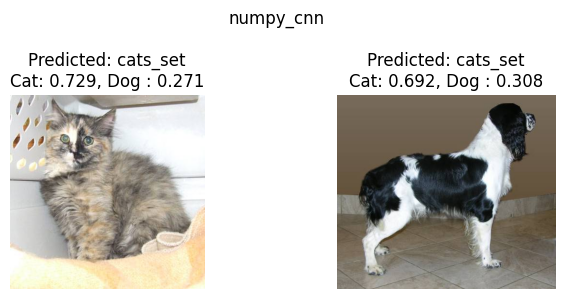


--- Проверка модели на GPU (Numba) ---
----------forward---------
Conv2d_layer (1, 1, 16, 16)
ReLU_layer (1, 4, 16, 16)
MaxPool2D_layer (1, 4, 16, 16)


100%|██████████| 4/4 [00:00<00:00, 3996.48it/s]



Flatten_layer (1, 4, 8, 8)
Linear_layer (1, 256)
ReLU_layer (1, 16)
Linear_layer (1, 16)
Flatten_layer (1, 2)
Softmax_layer (1, 2)
----------forward---------
Conv2d_layer (1, 1, 16, 16)
ReLU_layer (1, 4, 16, 16)
MaxPool2D_layer (1, 4, 16, 16)


100%|██████████| 4/4 [00:00<?, ?it/s]



Flatten_layer (1, 4, 8, 8)
Linear_layer (1, 256)
ReLU_layer (1, 16)
Linear_layer (1, 16)
Flatten_layer (1, 2)
Softmax_layer (1, 2)


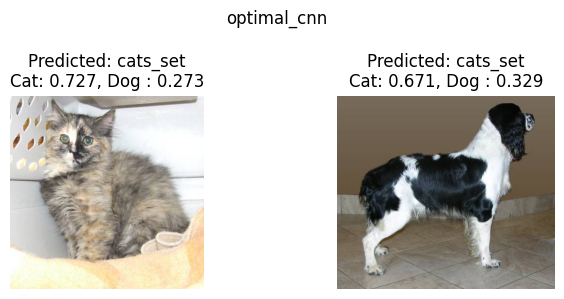

In [31]:
# Загрузка и проверка моделей на новых изображениях
model_np = Model.from_file('cnn_numpy.pkl')
model_opt = Model.from_file('cnn_optimal.pkl')

print("\n--- Проверка модели на CPU (NumPy) ---")
check_model(cat_img, dog_img, model_np, 'numpy_cnn')

print("\n--- Проверка модели на GPU (Numba) ---")
check_model(cat_img, dog_img, model_opt, 'optimal_cnn')